# Insurance Claims Profitability & Risk Analysis

## Identifying the Primary Drivers of Poor Portfolio Profitability

**Author:** Ajnur Sivac  
**Tools:** SQL, DuckDB, Jupyter Notebook  
**Data Sources:** Insurance claims, insurance agents, and vendors  
**Analysis Period:** June 2020 through June 2021

## Project Overview

This project analyzes an insurance claims portfolio to determine which products, customer segments, claim characteristics, agents, vendors, and operational factors are contributing most heavily to poor financial performance.

Three datasets are integrated into one analytical model:

- Insurance claims data
- Employee and insurance-agent data
- Vendor data

SQL is used to validate and clean the source data, join the datasets, engineer financial and risk metrics, compare portfolio segments, rank operational entities, analyze claim trends, and create an explainable claim-review scoring system.

Python is used only to establish the DuckDB connection, locate the source files, and display SQL query results.

## Central Business Question

### Which factors are driving poor profitability in the insurance claims portfolio, and where should the company intervene first?

The analysis answers this question by evaluating:

- Overall portfolio financial performance
- Insurance product profitability
- Customer risk segmentation
- Claim severity and documentation
- Reporting behavior
- Policy age at the time of loss
- Agent portfolio performance
- Vendor-associated claim performance
- Monthly changes in claim costs
- Concentration of financial exposure
- Claims requiring additional human review

## Analytical Approach

The project follows five analytical stages:

1. Validate the quality and completeness of the source data.
2. Create a clean relational claims dataset.
3. Calculate portfolio profitability and financial exposure.
4. Identify the products, segments, and operational factors associated with the greatest losses.
5. Prioritize areas for business intervention.

The final recommendations focus on where pricing, underwriting, claims management, vendor oversight, and operational review should be strengthened.

## Core Metrics

### Approved Claim Cost

The claim amount associated with an approved claim.

`Approved Claim Cost = Claim Amount when Claim Status = Approved`

### Underwriting Margin Proxy

A simplified measure of financial performance.

`Underwriting Margin Proxy = Premium Amount - Approved Claim Cost`

### Loss Ratio Proxy

The amount of approved claim cost relative to recorded premium.

`Loss Ratio Proxy = Approved Claim Cost / Premium Amount`

### Claim-to-Premium Ratio

The financial size of an individual claim relative to its associated premium.

`Claim-to-Premium Ratio = Claim Amount / Premium Amount`

### Denial Rate

The percentage of claims that were denied.

`Denial Rate = Denied Claims / Total Claims`

### Reporting Delay

The number of days between the loss date and the date the loss was reported.

### Policy Age at Loss

The number of days between policy inception and the date of loss.

### Claim Review Score

An explainable rules-based score used to prioritize claims for additional human review.

## Project Limitations

The dataset does not contain all fields needed for formal insurance profitability modeling.

Missing information includes:

- Policy limits
- Earned premium
- Exposure duration
- Claim reserves
- Actual claim payments
- Operating expenses
- Agent commissions
- Reinsurance
- Salvage recoveries
- Subrogation recoveries
- Investment income

The profitability measures in this project are therefore simplified analytical proxies.

The loss ratio is most useful for comparing products, customer segments, agents, vendors, and claim characteristics within this dataset. It should not be interpreted as an audited insurance-company loss ratio.

# 1. Environment Setup

DuckDB is used as the SQL engine inside Jupyter Notebook.

All cleaning, transformations, calculations, joins, rankings, and analysis are written in SQL.

In [1]:
import duckdb
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

conn = duckdb.connect(database=":memory:")

print("DuckDB connection established.")

DuckDB connection established.


# 2. Define the Source File Locations

The three CSV files are expected inside:

`/Users/ajnursivac/Desktop/projects/Finance`

In [2]:
project_path = Path("/Users/ajnursivac/Desktop/projects/Finance")

insurance_file = project_path / "insurance_data.csv"
employee_file = project_path / "employee_data.csv"
vendor_file = project_path / "vendor_data.csv"

files = {
    "Insurance Claims Data": insurance_file,
    "Employee Data": employee_file,
    "Vendor Data": vendor_file
}

for file_name, file_path in files.items():
    print(f"{file_name}: {file_path.exists()} — {file_path}")

Insurance Claims Data: True — /Users/ajnursivac/Desktop/projects/Finance/insurance_data.csv
Employee Data: True — /Users/ajnursivac/Desktop/projects/Finance/employee_data.csv
Vendor Data: True — /Users/ajnursivac/Desktop/projects/Finance/vendor_data.csv


## File Validation

Each file should return `True`.

A `False` result usually means that:

- The filename is different
- The file extension is different
- The file is stored in another folder

# 3. Load the Source Data into DuckDB

The source files are loaded into three raw SQL tables:

- `insurance_raw`
- `employee_raw`
- `vendor_raw`

In [3]:
conn.sql(f"""
CREATE OR REPLACE TABLE insurance_raw AS
SELECT *
FROM read_csv_auto(
    '{insurance_file.as_posix()}',
    HEADER = TRUE,
    SAMPLE_SIZE = -1
);

CREATE OR REPLACE TABLE employee_raw AS
SELECT *
FROM read_csv_auto(
    '{employee_file.as_posix()}',
    HEADER = TRUE,
    SAMPLE_SIZE = -1
);

CREATE OR REPLACE TABLE vendor_raw AS
SELECT *
FROM read_csv_auto(
    '{vendor_file.as_posix()}',
    HEADER = TRUE,
    SAMPLE_SIZE = -1
);
""")

conn.sql("""
SHOW TABLES;
""").df()

,name
0,employee_raw
1,insurance_raw
2,vendor_raw


# 4. Inspect the Source Tables

The following queries review the structure and initial records from each dataset.

In [4]:
conn.sql("""
DESCRIBE insurance_raw;
""").df()

,column_name,column_type,null,key,default,extra
0,TXN_DATE_TIME,TIMESTAMP,YES,None,None,None
1,TRANSACTION_ID,VARCHAR,YES,None,None,None
2,CUSTOMER_ID,VARCHAR,YES,None,None,None
3,POLICY_NUMBER,VARCHAR,YES,None,None,None
4,POLICY_EFF_DT,DATE,YES,None,None,None
5,LOSS_DT,DATE,YES,None,None,None
6,REPORT_DT,DATE,YES,None,None,None
7,INSURANCE_TYPE,VARCHAR,YES,None,None,None
8,PREMIUM_AMOUNT,DOUBLE,YES,None,None,None
9,CLAIM_AMOUNT,BIGINT,YES,None,None,None


In [5]:
conn.sql("""
DESCRIBE employee_raw;
""").df()

,column_name,column_type,null,key,default,extra
0,AGENT_ID,VARCHAR,YES,None,None,None
1,AGENT_NAME,VARCHAR,YES,None,None,None
2,DATE_OF_JOINING,DATE,YES,None,None,None
3,ADDRESS_LINE1,VARCHAR,YES,None,None,None
4,ADDRESS_LINE2,VARCHAR,YES,None,None,None
5,CITY,VARCHAR,YES,None,None,None
6,STATE,VARCHAR,YES,None,None,None
7,POSTAL_CODE,VARCHAR,YES,None,None,None
8,EMP_ROUTING_NUMBER,VARCHAR,YES,None,None,None
9,EMP_ACCT_NUMBER,VARCHAR,YES,None,None,None


In [6]:
conn.sql("""
DESCRIBE vendor_raw;
""").df()

,column_name,column_type,null,key,default,extra
0,VENDOR_ID,VARCHAR,YES,None,None,None
1,VENDOR_NAME,VARCHAR,YES,None,None,None
2,ADDRESS_LINE1,VARCHAR,YES,None,None,None
3,ADDRESS_LINE2,VARCHAR,YES,None,None,None
4,CITY,VARCHAR,YES,None,None,None
5,STATE,VARCHAR,YES,None,None,None
6,POSTAL_CODE,VARCHAR,YES,None,None,None


In [7]:
conn.sql("""
SELECT *
FROM insurance_raw
LIMIT 5;
""").df()

,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CUSTOMER_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,SSN,MARITAL_STATUS,AGE,TENURE,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,HOUSE_TYPE,SOCIAL_CLASS,ROUTING_NUMBER,ACCT_NUMBER,CUSTOMER_EDUCATION_LEVEL,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID
0,2020-06-01,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,Christopher Demarest,7701 West Saint John Road,#2010,Glendale,AZ,85308,087-11-1946,Y,54,89,Y,3,L,Own,LI,109134974,HXJP58258181908465,Bachelor,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556
1,2020-06-01,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,Ricardo Gatlin,8595 West 81st Drive,None,Arvada,CO,80005,685-33-3536,N,61,80,Y,4,L,Rent,MI,040125819,JUND46859540983731,Bachelor,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592
2,2020-06-01,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,Lashawn Engles,637 Britannia Drive,None,Vallejo,CA,94591,378-36-0672,N,47,68,Y,6,L,Rent,MI,099513168,WGZZ90128415227650,PhD,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031
3,2020-06-01,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,Steven Bassett,2803 River Drive,None,Thunderbolt,GA,31404,669-92-1861,Y,36,16,Y,7,L,Mortgage,MI,018429110,WIKE91555436351397,Masters,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075
4,2020-06-01,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,Jason Rodriguez,7573 National Drive,None,Livermore,CA,94550,703-40-1033,Y,51,16,Y,2,M,Rent,HI,070752391,VYJW71311537294027,Masters,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472


In [8]:
conn.sql("""
SELECT *
FROM employee_raw
LIMIT 5;
""").df()

,AGENT_ID,AGENT_NAME,DATE_OF_JOINING,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER
0,AGENT00001,Ray Johns,1993-06-05,1402 Maggies Way,None,Waterbury Center,VT,05677,034584958,HKUN51252328472585
1,AGENT00002,Angelo Borjon,2005-12-27,414 Tanya Pass,None,Panama City,FL,32404,107363763,OPIS19290040088204
2,AGENT00003,Candy Spellman,2003-09-02,606 National Street,#306,Fayetteville,AR,72701,081744097,YSCJ67489688482590
3,AGENT00004,Mary Smith,2004-09-23,235 Hugh Thomas Drive,None,Panama City,FL,32404,067563771,ZANG21285355574581
4,AGENT00005,Mildred Diaz,2011-06-21,3426 Broadview Street,None,Montgomery,AL,36110,114951317,DZFS82244494451134


In [9]:
conn.sql("""
SELECT *
FROM vendor_raw
LIMIT 5;
""").df()

,VENDOR_ID,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,VNDR00001,"King, Proctor and Jones",2027 North Shannon Drive,#5,Fayetteville,AR,72703
1,VNDR00002,Garcia Ltd,5701 East Shirley Lane,None,Montgomery,AL,36117
2,VNDR00003,Cherry LLC,1217 Cottondale Road,None,Montgomery,AL,36109
3,VNDR00004,Mays-Benson,227 West Montgomery Cross Road,#736,Savannah,GA,31406
4,VNDR00005,Wilson PLC,23 North Hill Street,None,Nashville,TN,37210


# 5. Data Quality Assessment

Before identifying profitability drivers, the source data must be checked for:

- Duplicate claims
- Missing identifiers
- Missing financial values
- Invalid dates
- Unexpected claim-status values
- Unexpected risk categories
- Incomplete agent or vendor joins

In [10]:
conn.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT TRANSACTION_ID) AS unique_transactions,
    COUNT(*) - COUNT(DISTINCT TRANSACTION_ID) AS duplicate_transactions,
    COUNT(DISTINCT POLICY_NUMBER) AS unique_policies,
    COUNT(DISTINCT CUSTOMER_ID) AS unique_customers,
    COUNT(DISTINCT AGENT_ID) AS unique_agents,
    COUNT(DISTINCT VENDOR_ID) AS unique_vendors
FROM insurance_raw;
""").df()

,total_rows,unique_transactions,duplicate_transactions,unique_policies,unique_customers,unique_agents,unique_vendors
0,10000,10000,0,10000,10000,1200,407


## Data-Volume Insight

This query confirms whether each transaction ID is unique and establishes the size of the claims portfolio.

Duplicate transactions could overstate claim cost and distort profitability measurements.

In [11]:
conn.sql("""
SELECT
    MIN(TRY_CAST(TXN_DATE_TIME AS TIMESTAMP)) AS first_transaction,
    MAX(TRY_CAST(TXN_DATE_TIME AS TIMESTAMP)) AS last_transaction,
    MIN(TRY_CAST(LOSS_DT AS DATE)) AS earliest_loss_date,
    MAX(TRY_CAST(LOSS_DT AS DATE)) AS latest_loss_date,
    MIN(TRY_CAST(REPORT_DT AS DATE)) AS earliest_report_date,
    MAX(TRY_CAST(REPORT_DT AS DATE)) AS latest_report_date
FROM insurance_raw;
""").df()

,first_transaction,last_transaction,earliest_loss_date,latest_loss_date,earliest_report_date,latest_report_date
0,2020-06-01,2021-06-30,2020-05-12,2021-06-29,2020-05-17,2021-06-29


In [12]:
conn.sql("""
SELECT
    SUM(CASE WHEN TRANSACTION_ID IS NULL THEN 1 ELSE 0 END)
        AS missing_transaction_id,

    SUM(CASE WHEN CUSTOMER_ID IS NULL THEN 1 ELSE 0 END)
        AS missing_customer_id,

    SUM(CASE WHEN POLICY_NUMBER IS NULL THEN 1 ELSE 0 END)
        AS missing_policy_number,

    SUM(CASE WHEN INSURANCE_TYPE IS NULL THEN 1 ELSE 0 END)
        AS missing_insurance_type,

    SUM(CASE WHEN PREMIUM_AMOUNT IS NULL THEN 1 ELSE 0 END)
        AS missing_premium_amount,

    SUM(CASE WHEN CLAIM_AMOUNT IS NULL THEN 1 ELSE 0 END)
        AS missing_claim_amount,

    SUM(CASE WHEN CLAIM_STATUS IS NULL THEN 1 ELSE 0 END)
        AS missing_claim_status,

    SUM(CASE WHEN AGENT_ID IS NULL THEN 1 ELSE 0 END)
        AS missing_agent_id,

    SUM(CASE WHEN VENDOR_ID IS NULL THEN 1 ELSE 0 END)
        AS missing_vendor_id,

    SUM(CASE WHEN AUTHORITY_CONTACTED IS NULL THEN 1 ELSE 0 END)
        AS missing_authority_contacted,

    SUM(CASE WHEN INCIDENT_CITY IS NULL THEN 1 ELSE 0 END)
        AS missing_incident_city

FROM insurance_raw;
""").df()

,missing_transaction_id,missing_customer_id,missing_policy_number,missing_insurance_type,missing_premium_amount,missing_claim_amount,missing_claim_status,missing_agent_id,missing_vendor_id,missing_authority_contacted,missing_incident_city
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"3,245.00",0.00,46.00


In [13]:
conn.sql("""
SELECT
    SUM(CASE WHEN TRANSACTION_ID IS NULL THEN 1 ELSE 0 END)
        AS missing_transaction_id,

    SUM(CASE WHEN CUSTOMER_ID IS NULL THEN 1 ELSE 0 END)
        AS missing_customer_id,

    SUM(CASE WHEN POLICY_NUMBER IS NULL THEN 1 ELSE 0 END)
        AS missing_policy_number,

    SUM(CASE WHEN INSURANCE_TYPE IS NULL THEN 1 ELSE 0 END)
        AS missing_insurance_type,

    SUM(CASE WHEN PREMIUM_AMOUNT IS NULL THEN 1 ELSE 0 END)
        AS missing_premium_amount,

    SUM(CASE WHEN CLAIM_AMOUNT IS NULL THEN 1 ELSE 0 END)
        AS missing_claim_amount,

    SUM(CASE WHEN CLAIM_STATUS IS NULL THEN 1 ELSE 0 END)
        AS missing_claim_status,

    SUM(CASE WHEN AGENT_ID IS NULL THEN 1 ELSE 0 END)
        AS missing_agent_id,

    SUM(CASE WHEN VENDOR_ID IS NULL THEN 1 ELSE 0 END)
        AS missing_vendor_id,

    SUM(CASE WHEN AUTHORITY_CONTACTED IS NULL THEN 1 ELSE 0 END)
        AS missing_authority_contacted,

    SUM(CASE WHEN INCIDENT_CITY IS NULL THEN 1 ELSE 0 END)
        AS missing_incident_city

FROM insurance_raw;
""").df()

,missing_transaction_id,missing_customer_id,missing_policy_number,missing_insurance_type,missing_premium_amount,missing_claim_amount,missing_claim_status,missing_agent_id,missing_vendor_id,missing_authority_contacted,missing_incident_city
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"3,245.00",0.00,46.00


In [14]:
conn.sql("""
SELECT
    RISK_SEGMENTATION,
    COUNT(*) AS claim_count,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS percent_of_claims
FROM insurance_raw
GROUP BY RISK_SEGMENTATION
ORDER BY claim_count DESC;
""").df()

,RISK_SEGMENTATION,claim_count,percent_of_claims
0,L,4395,43.95
1,M,4150,41.50
2,H,1455,14.55


In [15]:
conn.sql("""
SELECT
    COUNT(*) AS total_claims,

    COUNT(e.AGENT_ID)
        AS matched_agent_records,

    COUNT(*) - COUNT(e.AGENT_ID)
        AS unmatched_agent_records,

    COUNT(i.VENDOR_ID)
        AS claims_with_vendor_id,

    COUNT(v.VENDOR_ID)
        AS matched_vendor_records,

    COUNT(i.VENDOR_ID) - COUNT(v.VENDOR_ID)
        AS unmatched_vendor_records

FROM insurance_raw AS i

LEFT JOIN employee_raw AS e
    ON i.AGENT_ID = e.AGENT_ID

LEFT JOIN vendor_raw AS v
    ON i.VENDOR_ID = v.VENDOR_ID;
""").df()

,total_claims,matched_agent_records,unmatched_agent_records,claims_with_vendor_id,matched_vendor_records,unmatched_vendor_records
0,10000,10000,0,6755,6755,0


## Data-Quality Interpretation

The portfolio analysis can proceed when:

- Transaction IDs are unique
- Premium and claim amounts are present
- Claim-status values are valid
- Agent IDs match the employee table
- Vendor IDs match when a vendor is recorded
- Date relationships are logically valid

Missing vendor values are preserved because some claims may not require an external vendor.

# 6. Create the Clean Analytical Claims Table

The clean table creates the financial and operational variables needed to answer the central business question.

Transformations include:

- Standardizing dates
- Translating coded categories
- Creating approved claim cost
- Creating denied claim amount
- Calculating underwriting margin
- Calculating loss ratio
- Calculating claim-to-premium ratio
- Calculating reporting delay
- Calculating policy age at loss
- Creating customer age bands
- Creating reporting-delay bands
- Creating incident time categories
- Joining agent and vendor information
- Excluding unnecessary personal and banking information

In [16]:
conn.sql("""
CREATE OR REPLACE TABLE claims_clean AS

SELECT
    i.TRANSACTION_ID AS transaction_id,
    i.CUSTOMER_ID AS customer_id,
    i.POLICY_NUMBER AS policy_number,

    TRY_CAST(i.TXN_DATE_TIME AS TIMESTAMP)
        AS transaction_timestamp,

    TRY_CAST(i.POLICY_EFF_DT AS DATE)
        AS policy_effective_date,

    TRY_CAST(i.LOSS_DT AS DATE)
        AS loss_date,

    TRY_CAST(i.REPORT_DT AS DATE)
        AS report_date,

    i.INSURANCE_TYPE AS insurance_type,

    CAST(i.PREMIUM_AMOUNT AS DOUBLE)
        AS premium_amount,

    CAST(i.CLAIM_AMOUNT AS DOUBLE)
        AS claim_amount,

    CASE
        WHEN i.CLAIM_STATUS = 'A' THEN 'Approved'
        WHEN i.CLAIM_STATUS = 'D' THEN 'Denied'
        ELSE 'Unknown'
    END AS claim_status,

    CASE
        WHEN i.CLAIM_STATUS = 'A'
        THEN CAST(i.CLAIM_AMOUNT AS DOUBLE)
        ELSE 0
    END AS approved_claim_cost,

    CASE
        WHEN i.CLAIM_STATUS = 'D'
        THEN CAST(i.CLAIM_AMOUNT AS DOUBLE)
        ELSE 0
    END AS denied_claim_amount,

    CAST(i.PREMIUM_AMOUNT AS DOUBLE)
    -
    CASE
        WHEN i.CLAIM_STATUS = 'A'
        THEN CAST(i.CLAIM_AMOUNT AS DOUBLE)
        ELSE 0
    END AS underwriting_margin_proxy,

    CASE
        WHEN CAST(i.PREMIUM_AMOUNT AS DOUBLE) > 0
        THEN
            CASE
                WHEN i.CLAIM_STATUS = 'A'
                THEN CAST(i.CLAIM_AMOUNT AS DOUBLE)
                     / CAST(i.PREMIUM_AMOUNT AS DOUBLE)
                ELSE 0
            END
        ELSE NULL
    END AS loss_ratio_proxy,

    CASE
        WHEN CAST(i.PREMIUM_AMOUNT AS DOUBLE) > 0
        THEN CAST(i.CLAIM_AMOUNT AS DOUBLE)
             / CAST(i.PREMIUM_AMOUNT AS DOUBLE)
        ELSE NULL
    END AS claim_to_premium_ratio,

    DATE_DIFF(
        'day',
        TRY_CAST(i.LOSS_DT AS DATE),
        TRY_CAST(i.REPORT_DT AS DATE)
    ) AS reporting_delay_days,

    DATE_DIFF(
        'day',
        TRY_CAST(i.POLICY_EFF_DT AS DATE),
        TRY_CAST(i.LOSS_DT AS DATE)
    ) AS policy_age_at_loss_days,

    i.AGE AS customer_age,
    i.TENURE AS customer_tenure,
    i.EMPLOYMENT_STATUS AS employment_status,
    i.MARITAL_STATUS AS marital_status,
    i.NO_OF_FAMILY_MEMBERS AS family_members,

    CASE
        WHEN i.AGE BETWEEN 18 AND 29 THEN '18-29'
        WHEN i.AGE BETWEEN 30 AND 39 THEN '30-39'
        WHEN i.AGE BETWEEN 40 AND 49 THEN '40-49'
        WHEN i.AGE BETWEEN 50 AND 59 THEN '50-59'
        WHEN i.AGE >= 60 THEN '60+'
        ELSE 'Unknown'
    END AS customer_age_band,

    CASE
        WHEN i.RISK_SEGMENTATION = 'H' THEN 'High'
        WHEN i.RISK_SEGMENTATION = 'M' THEN 'Medium'
        WHEN i.RISK_SEGMENTATION = 'L' THEN 'Low'
        ELSE 'Unknown'
    END AS risk_segment,

    i.HOUSE_TYPE AS house_type,
    i.SOCIAL_CLASS AS social_class,

    COALESCE(
        i.CUSTOMER_EDUCATION_LEVEL,
        'Unknown'
    ) AS education_level,

    i.INCIDENT_SEVERITY AS incident_severity,

    COALESCE(
        i.AUTHORITY_CONTACTED,
        'None Reported'
    ) AS authority_contacted,

    CASE
        WHEN i.ANY_INJURY = 1 THEN 'Yes'
        WHEN i.ANY_INJURY = 0 THEN 'No'
        ELSE 'Unknown'
    END AS any_injury,

    CASE
        WHEN i.POLICE_REPORT_AVAILABLE = 1 THEN 'Yes'
        WHEN i.POLICE_REPORT_AVAILABLE = 0 THEN 'No'
        ELSE 'Unknown'
    END AS police_report_available,

    i.INCIDENT_STATE AS incident_state,

    COALESCE(
        i.INCIDENT_CITY,
        'Unknown'
    ) AS incident_city,

    i.INCIDENT_HOUR_OF_THE_DAY
        AS incident_hour,

    CASE
        WHEN i.INCIDENT_HOUR_OF_THE_DAY BETWEEN 0 AND 5
            THEN 'Overnight'
        WHEN i.INCIDENT_HOUR_OF_THE_DAY BETWEEN 6 AND 11
            THEN 'Morning'
        WHEN i.INCIDENT_HOUR_OF_THE_DAY BETWEEN 12 AND 17
            THEN 'Afternoon'
        WHEN i.INCIDENT_HOUR_OF_THE_DAY BETWEEN 18 AND 23
            THEN 'Evening'
        ELSE 'Unknown'
    END AS incident_time_band,

    CASE
        WHEN DATE_DIFF(
            'day',
            TRY_CAST(i.LOSS_DT AS DATE),
            TRY_CAST(i.REPORT_DT AS DATE)
        ) = 0
            THEN 'Same Day'

        WHEN DATE_DIFF(
            'day',
            TRY_CAST(i.LOSS_DT AS DATE),
            TRY_CAST(i.REPORT_DT AS DATE)
        ) BETWEEN 1 AND 3
            THEN '1-3 Days'

        WHEN DATE_DIFF(
            'day',
            TRY_CAST(i.LOSS_DT AS DATE),
            TRY_CAST(i.REPORT_DT AS DATE)
        ) BETWEEN 4 AND 7
            THEN '4-7 Days'

        WHEN DATE_DIFF(
            'day',
            TRY_CAST(i.LOSS_DT AS DATE),
            TRY_CAST(i.REPORT_DT AS DATE)
        ) BETWEEN 8 AND 14
            THEN '8-14 Days'

        WHEN DATE_DIFF(
            'day',
            TRY_CAST(i.LOSS_DT AS DATE),
            TRY_CAST(i.REPORT_DT AS DATE)
        ) > 14
            THEN 'More Than 14 Days'

        ELSE 'Invalid or Missing'
    END AS reporting_delay_band,

    i.AGENT_ID AS agent_id,

    COALESCE(
        e.AGENT_NAME,
        'Unknown Agent'
    ) AS agent_name,

    TRY_CAST(e.DATE_OF_JOINING AS DATE)
        AS agent_join_date,

    COALESCE(
        e.STATE,
        'Unknown'
    ) AS agent_state,

    COALESCE(
        i.VENDOR_ID,
        'NO_VENDOR'
    ) AS vendor_id,

    COALESCE(
        v.VENDOR_NAME,
        'No Vendor Assigned'
    ) AS vendor_name,

    COALESCE(
        v.STATE,
        'Unknown'
    ) AS vendor_state

FROM insurance_raw AS i

LEFT JOIN employee_raw AS e
    ON i.AGENT_ID = e.AGENT_ID

LEFT JOIN vendor_raw AS v
    ON i.VENDOR_ID = v.VENDOR_ID;
""")

conn.sql("""
SELECT *
FROM claims_clean
LIMIT 5;
""").df()

,transaction_id,customer_id,policy_number,transaction_timestamp,policy_effective_date,loss_date,report_date,insurance_type,premium_amount,claim_amount,claim_status,approved_claim_cost,denied_claim_amount,underwriting_margin_proxy,loss_ratio_proxy,claim_to_premium_ratio,reporting_delay_days,policy_age_at_loss_days,customer_age,customer_tenure,employment_status,marital_status,family_members,customer_age_band,risk_segment,house_type,social_class,education_level,incident_severity,authority_contacted,any_injury,police_report_available,incident_state,incident_city,incident_hour,incident_time_band,reporting_delay_band,agent_id,agent_name,agent_join_date,agent_state,vendor_id,vendor_name,vendor_state
0,TXN00000001,A00003822,PLC00008468,2020-06-01,2015-06-23,2020-05-16,2020-05-21,Health,157.13,"9,000.00",Approved,"9,000.00",0.00,"-8,842.87",57.28,57.28,5,1789,54,89,Y,Y,3,50-59,Low,Own,LI,Bachelor,Major Loss,Police,No,Yes,GA,Savannah,4,Overnight,4-7 Days,AGENT00413,Amy Wangler,1994-01-06,TN,VNDR00556,Ramsey Inc,FL
1,TXN00000002,A00008149,PLC00009594,2020-06-01,2018-04-21,2020-05-13,2020-05-18,Property,141.71,"26,000.00",Approved,"26,000.00",0.00,"-25,858.29",183.47,183.47,5,753,61,80,Y,N,4,60+,Low,Rent,MI,Bachelor,Total Loss,Ambulance,Yes,No,AL,Montgomery,0,Overnight,4-7 Days,AGENT00769,Jessica Montez,2004-05-28,AZ,VNDR00592,"Morales, Campbell and Washington",AR
2,TXN00000003,A00003172,PLC00007969,2020-06-01,2019-10-03,2020-05-21,2020-05-26,Property,157.24,"13,000.00",Approved,"13,000.00",0.00,"-12,842.76",82.68,82.68,5,231,47,68,Y,N,6,40-49,Low,Rent,MI,PhD,Total Loss,Police,No,Yes,CO,Grand Junction,19,Evening,4-7 Days,AGENT00883,Howard Smith,2004-08-01,AL,VNDR00031,Johnson Ltd,AR
3,TXN00000004,A00007572,PLC00009292,2020-06-01,2016-11-29,2020-05-14,2020-05-19,Health,172.87,"16,000.00",Approved,"16,000.00",0.00,"-15,827.13",92.56,92.56,5,1262,36,16,Y,Y,7,30-39,Low,Mortgage,MI,Masters,Minor Loss,Ambulance,No,No,GA,Savannah,12,Afternoon,4-7 Days,AGENT00278,Patricia Tucker,2007-06-12,OK,VNDR00075,Blackwell-Foster,TN
4,TXN00000005,A00008173,PLC00000204,2020-06-01,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,"3,000.00",Approved,"3,000.00",0.00,"-2,911.47",33.89,33.89,5,3065,51,16,Y,Y,2,50-59,Medium,Rent,HI,Masters,Major Loss,Police,No,Yes,TN,Nashville,18,Evening,4-7 Days,AGENT00636,Brenda Bean,2010-01-19,MD,VNDR00472,Evans-Scott,DC


## Clean-Table Validation

The analytical table is checked for duplicate transactions, negative financial values, invalid reporting delays, and losses occurring before policy inception.

In [17]:
conn.sql("""
SELECT
    COUNT(*) AS total_clean_rows,

    COUNT(DISTINCT transaction_id)
        AS unique_transactions,

    COUNT(*) - COUNT(DISTINCT transaction_id)
        AS duplicate_transactions,

    SUM(
        CASE
            WHEN reporting_delay_days < 0
            THEN 1
            ELSE 0
        END
    ) AS negative_reporting_delays,

    SUM(
        CASE
            WHEN policy_age_at_loss_days < 0
            THEN 1
            ELSE 0
        END
    ) AS losses_before_policy_inception,

    SUM(
        CASE
            WHEN premium_amount <= 0
            THEN 1
            ELSE 0
        END
    ) AS nonpositive_premiums,

    SUM(
        CASE
            WHEN claim_amount < 0
            THEN 1
            ELSE 0
        END
    ) AS negative_claim_amounts

FROM claims_clean;
""").df()

,total_clean_rows,unique_transactions,duplicate_transactions,negative_reporting_delays,losses_before_policy_inception,nonpositive_premiums,negative_claim_amounts
0,10000,10000,0,0.00,0.00,0.00,0.00


# 7. Establish the Portfolio Profitability Baseline

The first step in identifying poor-profitability drivers is to calculate the overall financial position of the portfolio.

In [18]:
conn.sql("""
SELECT
    COUNT(*) AS total_claims,

    COUNT(DISTINCT customer_id)
        AS unique_customers,

    COUNT(DISTINCT policy_number)
        AS unique_policies,

    COUNT(DISTINCT agent_id)
        AS active_agents,

    COUNT(
        DISTINCT CASE
            WHEN vendor_id <> 'NO_VENDOR'
            THEN vendor_id
        END
    ) AS active_vendors,

    ROUND(
        SUM(premium_amount),
        2
    ) AS total_premium,

    ROUND(
        SUM(claim_amount),
        2
    ) AS total_claim_amount,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        SUM(denied_claim_amount),
        2
    ) AS denied_claim_amount,

    ROUND(
        SUM(underwriting_margin_proxy),
        2
    ) AS underwriting_margin_proxy,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent,

    ROUND(
        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Approved'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS approval_rate_percent,

    ROUND(
        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS denial_rate_percent

FROM claims_clean;
""").df()

,total_claims,unique_customers,unique_policies,active_agents,active_vendors,total_premium,total_claim_amount,approved_claim_cost,denied_claim_amount,underwriting_margin_proxy,loss_ratio_percent,approval_rate_percent,denial_rate_percent
0,10000,10000,10000,1200,407,"885,085.95","165,638,300.00","157,182,500.00","8,455,800.00","-156,297,414.05","17,759.01",94.97,5.03


## Baseline Interpretation

The overall loss ratio establishes the benchmark against which all products, customer segments, agents, vendors, and claim categories are compared.

A negative underwriting-margin proxy indicates that approved claim costs exceed the recorded premium amounts in the dataset.

Because recorded premium may not represent earned annual premium, the absolute loss ratio should be interpreted cautiously. The relative comparisons remain useful for identifying the strongest drivers of poor performance.

# 8. Determine Whether Large Claims Are Driving Poor Profitability

Claim percentiles are used to determine whether financial losses are broadly distributed or influenced by a smaller number of unusually large claims.

In [19]:
conn.sql("""
SELECT
    ROUND(MIN(claim_amount), 2)
        AS minimum_claim,

    ROUND(QUANTILE_CONT(claim_amount, 0.25), 2)
        AS first_quartile,

    ROUND(MEDIAN(claim_amount), 2)
        AS median_claim,

    ROUND(AVG(claim_amount), 2)
        AS average_claim,

    ROUND(QUANTILE_CONT(claim_amount, 0.75), 2)
        AS third_quartile,

    ROUND(QUANTILE_CONT(claim_amount, 0.90), 2)
        AS percentile_90,

    ROUND(QUANTILE_CONT(claim_amount, 0.95), 2)
        AS percentile_95,

    ROUND(QUANTILE_CONT(claim_amount, 0.99), 2)
        AS percentile_99,

    ROUND(MAX(claim_amount), 2)
        AS maximum_claim

FROM claims_clean;
""").df()

,minimum_claim,first_quartile,median_claim,average_claim,third_quartile,percentile_90,percentile_95,percentile_99,maximum_claim
0,100.00,"2,000.00","7,000.00","16,563.83","21,000.00","45,000.00","72,000.00","95,000.00","100,000.00"


## Large-Claim Interpretation

A large difference between the median and average claim amount indicates that high-value claims are pulling the average upward.

The 90th, 95th, and 99th percentiles can be used to establish large-loss review thresholds and identify claims that require specialized handling.

## Large-Claim Interpretation

A large difference between the median and average claim amount indicates that high-value claims are pulling the average upward.

The 90th, 95th, and 99th percentiles can be used to establish large-loss review thresholds and identify claims that require specialized handling.

In [20]:
conn.sql("""
SELECT
    insurance_type,

    COUNT(*) AS claim_count,

    ROUND(
        SUM(premium_amount),
        2
    ) AS total_premium,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        SUM(underwriting_margin_proxy),
        2
    ) AS underwriting_margin_proxy,

    ROUND(
        AVG(claim_amount),
        2
    ) AS average_claim_amount,

    ROUND(
        MEDIAN(claim_amount),
        2
    ) AS median_claim_amount,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent,

    ROUND(
        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS denial_rate_percent

FROM claims_clean

GROUP BY insurance_type

ORDER BY loss_ratio_percent DESC;
""").df()

,insurance_type,claim_count,total_premium,approved_claim_cost,underwriting_margin_proxy,average_claim_amount,median_claim_amount,loss_ratio_percent,denial_rate_percent
0,Life,1682,"125,621.22","86,815,000.00","-86,689,378.78","54,386.44","54,000.00","69,108.55",4.58
1,Property,1692,"202,285.83","39,454,000.00","-39,251,714.17","24,573.88","24,000.00","19,504.08",4.96
2,Health,1690,"252,455.73","17,347,000.00","-17,094,544.27","10,801.18","11,000.00","6,871.30",5.03
3,Motor,1574,"165,391.98","8,180,000.00","-8,014,608.02","5,503.81","6,000.00","4,945.83",5.40
4,Mobile,1692,"15,191.42","654,500.00","-639,308.58",406.80,400.00,"4,308.35",4.96
5,Travel,1670,"124,139.77","4,732,000.00","-4,607,860.23","2,979.64","3,000.00","3,811.83",5.27


## Product-Level Interpretation

Insurance products with the highest loss ratios and largest negative underwriting margins are the strongest product-level drivers of poor profitability.

These products should be prioritized for:

- Pricing review
- Underwriting review
- Coverage-design review
- Policy-limit review
- Claim-handling review
- Additional customer segmentation

## Product Intervention Ranking

Window functions rank each product by premium volume, approved claim cost, and loss-ratio risk.

In [21]:
conn.sql("""
WITH product_metrics AS (
    SELECT
        insurance_type,

        COUNT(*) AS claim_count,

        SUM(premium_amount)
            AS total_premium,

        SUM(approved_claim_cost)
            AS approved_claim_cost,

        SUM(underwriting_margin_proxy)
            AS underwriting_margin_proxy,

        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0)
            AS loss_ratio_percent

    FROM claims_clean

    GROUP BY insurance_type
)

SELECT
    insurance_type,
    claim_count,

    ROUND(total_premium, 2)
        AS total_premium,

    ROUND(approved_claim_cost, 2)
        AS approved_claim_cost,

    ROUND(underwriting_margin_proxy, 2)
        AS underwriting_margin_proxy,

    ROUND(loss_ratio_percent, 2)
        AS loss_ratio_percent,

    DENSE_RANK() OVER (
        ORDER BY total_premium DESC
    ) AS premium_volume_rank,

    DENSE_RANK() OVER (
        ORDER BY approved_claim_cost DESC
    ) AS claim_cost_rank,

    DENSE_RANK() OVER (
        ORDER BY loss_ratio_percent DESC
    ) AS intervention_priority_rank

FROM product_metrics

ORDER BY intervention_priority_rank;
""").df()

,insurance_type,claim_count,total_premium,approved_claim_cost,underwriting_margin_proxy,loss_ratio_percent,premium_volume_rank,claim_cost_rank,intervention_priority_rank
0,Life,1682,"125,621.22","86,815,000.00","-86,689,378.78","69,108.55",4,1,1
1,Property,1692,"202,285.83","39,454,000.00","-39,251,714.17","19,504.08",2,2,2
2,Health,1690,"252,455.73","17,347,000.00","-17,094,544.27","6,871.30",1,3,3
3,Motor,1574,"165,391.98","8,180,000.00","-8,014,608.02","4,945.83",3,4,4
4,Mobile,1692,"15,191.42","654,500.00","-639,308.58","4,308.35",6,6,5
5,Travel,1670,"124,139.77","4,732,000.00","-4,607,860.23","3,811.83",5,5,6


# 10. Determine Whether Customer Risk Segmentation Explains Poor Profitability

The existing High-, Medium-, and Low-risk classifications are compared to determine whether they meaningfully separate financial outcomes.

In [22]:
conn.sql("""
SELECT
    risk_segment,

    COUNT(*) AS claim_count,

    ROUND(
        SUM(premium_amount),
        2
    ) AS total_premium,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        AVG(claim_amount),
        2
    ) AS average_claim_amount,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent,

    ROUND(
        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS denial_rate_percent,

    ROUND(
        AVG(reporting_delay_days),
        2
    ) AS average_reporting_delay_days

FROM claims_clean

GROUP BY risk_segment

ORDER BY loss_ratio_percent DESC;
""").df()

,risk_segment,claim_count,total_premium,approved_claim_cost,average_claim_amount,loss_ratio_percent,denial_rate_percent,average_reporting_delay_days
0,High,1455,"128,281.18","23,541,400.00","16,825.43","18,351.41",4.12,3.19
1,Medium,4150,"364,928.51","64,728,300.00","16,519.25","17,737.25",5.33,3.22
2,Low,4395,"391,876.26","68,912,800.00","16,519.32","17,585.35",5.05,3.21


## Customer-Risk Interpretation

If High-risk customers have substantially higher loss ratios than Medium- and Low-risk customers, the current segmentation is useful for pricing and underwriting.

If the differences are small, the existing segmentation may not be separating customers effectively.

The company should then incorporate additional variables such as:

- Historical claim frequency
- Historical claim severity
- Policy limits
- Exposure duration
- Geographic risk
- Payment behavior
- Prior cancellations
- Previous coverage gaps

## Product and Customer Risk Interaction

This analysis identifies the product and customer-risk combinations creating the greatest financial exposure.

In [23]:
conn.sql("""
SELECT
    insurance_type,
    risk_segment,

    COUNT(*) AS claim_count,

    ROUND(
        SUM(premium_amount),
        2
    ) AS total_premium,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        SUM(underwriting_margin_proxy),
        2
    ) AS underwriting_margin_proxy,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent,

    ROUND(
        AVG(claim_amount),
        2
    ) AS average_claim_amount

FROM claims_clean

GROUP BY
    insurance_type,
    risk_segment

HAVING COUNT(*) >= 25

ORDER BY
    loss_ratio_percent DESC,
    approved_claim_cost DESC;
""").df()

,insurance_type,risk_segment,claim_count,total_premium,approved_claim_cost,underwriting_margin_proxy,loss_ratio_percent,average_claim_amount
0,Life,Low,731,"54,566.70","38,557,000.00","-38,502,433.30","70,660.31","55,482.90"
1,Life,High,251,"18,627.47","12,736,000.00","-12,717,372.53","68,372.14","52,992.03"
2,Life,Medium,700,"52,427.05","35,522,000.00","-35,469,572.95","67,755.10","53,741.43"
3,Property,High,265,"31,698.47","6,300,000.00","-6,268,301.53","19,874.78","24,403.77"
4,Property,Medium,708,"84,419.04","16,560,000.00","-16,475,580.96","19,616.43","24,884.18"
5,Property,Low,719,"86,168.32","16,594,000.00","-16,507,831.68","19,257.66","24,331.02"
6,Health,High,242,"36,193.17","2,590,000.00","-2,553,806.83","7,156.05","11,128.10"
7,Health,Low,753,"112,603.90","7,696,000.00","-7,583,396.10","6,834.58","10,811.42"
8,Health,Medium,695,"103,658.66","7,061,000.00","-6,957,341.34","6,811.78","10,676.26"
9,Motor,High,210,"21,952.19","1,117,000.00","-1,095,047.81","5,088.33","5,633.33"


## Product-Risk Interpretation

The highest-loss product and customer-risk combinations are more actionable than product or customer risk considered independently.

These combinations should receive the earliest pricing, underwriting, and claims-management intervention.


# 11. Determine Which Claim Characteristics Are Driving Losses

Incident severity, injuries, documentation, reporting delay, and policy age are analyzed to identify claim-level drivers of poor financial performance.


In [24]:
conn.sql("""
SELECT
    incident_severity,

    COUNT(*) AS claim_count,

    ROUND(
        AVG(claim_amount),
        2
    ) AS average_claim_amount,

    ROUND(
        MEDIAN(claim_amount),
        2
    ) AS median_claim_amount,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent,

    ROUND(
        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS denial_rate_percent

FROM claims_clean

GROUP BY incident_severity

ORDER BY loss_ratio_percent DESC;
""").df()

,incident_severity,claim_count,average_claim_amount,median_claim_amount,approved_claim_cost,loss_ratio_percent,denial_rate_percent
0,Major Loss,3317,"16,656.59","8,000.00","52,825,200.00","18,011.94",4.82
1,Total Loss,3390,"16,795.72","7,000.00","53,914,700.00","17,865.52",5.19
2,Minor Loss,3293,"16,231.67","7,000.00","50,442,600.00","17,392.42",5.07


## Severity Interpretation

The severity category with the highest approved claim cost and loss ratio is a major claim-level driver of poor profitability.

Severe claims may require:

- Specialized adjusters
- Higher approval authority
- Reserve review
- Legal review
- Vendor oversight
- Large-loss reporting

In [25]:
conn.sql("""
SELECT
    any_injury,
    police_report_available,

    COUNT(*) AS claim_count,

    ROUND(
        AVG(claim_amount),
        2
    ) AS average_claim_amount,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent,

    ROUND(
        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS denial_rate_percent

FROM claims_clean

GROUP BY
    any_injury,
    police_report_available

ORDER BY loss_ratio_percent DESC;
""").df()

,any_injury,police_report_available,claim_count,average_claim_amount,approved_claim_cost,loss_ratio_percent,denial_rate_percent
0,Yes,Yes,4810,"16,818.34","76,847,300.00","18,075.95",4.76
1,Yes,No,2181,"16,545.07","34,624,600.00","17,822.19",4.86
2,No,Yes,2118,"16,239.38","32,369,000.00","17,334.11",5.67
3,No,No,891,"16,007.07","13,341,600.00","16,901.70",5.39


## Injury and Documentation Interpretation

Injury-related claims may increase medical, legal, and settlement costs.

Police-report availability can improve documentation, but it should not be treated as a standalone measure of claim validity.

The most important intervention groups are those combining high claim severity, injuries, and incomplete documentation.

In [26]:
conn.sql("""
SELECT
    reporting_delay_band,

    COUNT(*) AS claim_count,

    ROUND(
        AVG(claim_amount),
        2
    ) AS average_claim_amount,

    ROUND(
        MEDIAN(claim_amount),
        2
    ) AS median_claim_amount,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS denial_rate_percent,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent

FROM claims_clean

GROUP BY reporting_delay_band

ORDER BY
    CASE reporting_delay_band
        WHEN 'Same Day' THEN 1
        WHEN '1-3 Days' THEN 2
        WHEN '4-7 Days' THEN 3
        WHEN '8-14 Days' THEN 4
        WHEN 'More Than 14 Days' THEN 5
        ELSE 6
    END;
""").df()

,reporting_delay_band,claim_count,average_claim_amount,median_claim_amount,approved_claim_cost,denial_rate_percent,loss_ratio_percent
0,Same Day,1565,"16,970.73","8,000.00","25,201,100.00",5.43,"18,137.82"
1,1-3 Days,3476,"16,220.20","7,000.00","53,695,500.00",5.32,"17,648.80"
2,4-7 Days,4959,"16,676.29","8,000.00","78,285,900.00",4.70,"17,715.79"


## Reporting-Delay Interpretation

Reporting delay becomes an important profitability driver when delayed claims also have:

- High claim amounts
- High claim-to-premium ratios
- Severe incidents
- Missing documentation
- Recently initiated policies

Delayed reporting should trigger additional review rather than automatic denial.

## Policy Age at the Time of Loss

Claims occurring shortly after policy inception are analyzed to determine whether early-policy losses are contributing disproportionately to poor profitability.

In [27]:
conn.sql("""
WITH policy_age_categories AS (
    SELECT
        *,

        CASE
            WHEN policy_age_at_loss_days BETWEEN 0 AND 30
                THEN '0-30 Days'

            WHEN policy_age_at_loss_days BETWEEN 31 AND 90
                THEN '31-90 Days'

            WHEN policy_age_at_loss_days BETWEEN 91 AND 365
                THEN '91-365 Days'

            WHEN policy_age_at_loss_days BETWEEN 366 AND 1095
                THEN '1-3 Years'

            WHEN policy_age_at_loss_days > 1095
                THEN 'More Than 3 Years'

            ELSE 'Invalid or Missing'
        END AS policy_age_band

    FROM claims_clean
)

SELECT
    policy_age_band,

    COUNT(*) AS claim_count,

    ROUND(
        AVG(claim_amount),
        2
    ) AS average_claim_amount,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS denial_rate_percent,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent

FROM policy_age_categories

GROUP BY policy_age_band

ORDER BY
    CASE policy_age_band
        WHEN '0-30 Days' THEN 1
        WHEN '31-90 Days' THEN 2
        WHEN '91-365 Days' THEN 3
        WHEN '1-3 Years' THEN 4
        WHEN 'More Than 3 Years' THEN 5
        ELSE 6
    END;
""").df()

,policy_age_band,claim_count,average_claim_amount,approved_claim_cost,denial_rate_percent,loss_ratio_percent
0,91-365 Days,240,"18,611.67","4,335,700.00",4.58,"20,895.48"
1,1-3 Years,1923,"17,032.76","31,269,800.00",4.89,"18,483.51"
2,More Than 3 Years,7837,"16,386.05","121,577,000.00",5.08,"17,489.07"


## Policy-Age Interpretation

Claims occurring early in the policy lifecycle may create greater financial pressure because relatively little premium has been collected before the loss.

Early-policy claims with high claim amounts or weak documentation should be prioritized for human review.

# 12. Determine Whether Poor Profitability Is Worsening Over Time

Monthly claim volume and approved claim cost are analyzed to identify periods of worsening financial performance.

In [28]:
conn.sql("""
SELECT
    CAST(
        DATE_TRUNC(
            'month',
            transaction_timestamp
        ) AS DATE
    ) AS transaction_month,

    COUNT(*) AS claim_count,

    ROUND(
        SUM(premium_amount),
        2
    ) AS total_premium,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        SUM(underwriting_margin_proxy),
        2
    ) AS underwriting_margin_proxy,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent,

    ROUND(
        AVG(claim_amount),
        2
    ) AS average_claim_amount

FROM claims_clean

GROUP BY transaction_month

ORDER BY transaction_month;
""").df()

,transaction_month,claim_count,total_premium,approved_claim_cost,underwriting_margin_proxy,loss_ratio_percent,average_claim_amount
0,2020-06-01,777,"68,618.80","12,507,500.00","-12,438,881.20","18,227.51","17,171.56"
1,2020-07-01,759,"66,185.29","10,965,900.00","-10,899,714.71","16,568.49","14,990.12"
2,2020-08-01,720,"63,778.54","11,004,300.00","-10,940,521.46","17,253.92","16,315.83"
3,2020-09-01,759,"67,082.01","12,582,200.00","-12,515,117.99","18,756.44","17,371.28"
4,2020-10-01,755,"66,463.60","12,116,600.00","-12,050,136.40","18,230.43","16,873.51"
5,2020-11-01,771,"66,255.23","11,926,100.00","-11,859,844.77","18,000.24","16,646.17"
6,2020-12-01,807,"73,124.51","11,929,700.00","-11,856,575.49","16,314.23","15,163.57"
7,2021-01-01,826,"71,117.16","13,885,200.00","-13,814,082.84","19,524.40","17,680.63"
8,2021-02-01,748,"67,201.73","12,250,400.00","-12,183,198.27","18,229.29","16,846.66"
9,2021-03-01,741,"68,797.83","11,970,200.00","-11,901,402.17","17,399.10","17,032.66"


## Monthly Trend Interpretation

Months with unusually high claim counts, approved claim costs, or loss ratios should be investigated for:

- Seasonal effects
- Catastrophic events
- Product-specific spikes
- Geographic concentration
- Operational backlogs
- Changes in approval behavior

In [29]:
conn.sql("""
WITH monthly_metrics AS (
    SELECT
        CAST(
            DATE_TRUNC(
                'month',
                transaction_timestamp
            ) AS DATE
        ) AS transaction_month,

        COUNT(*) AS claim_count,

        SUM(premium_amount)
            AS total_premium,

        SUM(approved_claim_cost)
            AS approved_claim_cost

    FROM claims_clean

    GROUP BY transaction_month
),

monthly_comparison AS (
    SELECT
        *,

        LAG(claim_count) OVER (
            ORDER BY transaction_month
        ) AS prior_month_claim_count,

        LAG(approved_claim_cost) OVER (
            ORDER BY transaction_month
        ) AS prior_month_claim_cost

    FROM monthly_metrics
)

SELECT
    transaction_month,
    claim_count,

    ROUND(
        total_premium,
        2
    ) AS total_premium,

    ROUND(
        approved_claim_cost,
        2
    ) AS approved_claim_cost,

    ROUND(
        100.0
        * (claim_count - prior_month_claim_count)
        / NULLIF(prior_month_claim_count, 0),
        2
    ) AS claim_count_month_over_month_percent,

    ROUND(
        100.0
        * (approved_claim_cost - prior_month_claim_cost)
        / NULLIF(prior_month_claim_cost, 0),
        2
    ) AS claim_cost_month_over_month_percent

FROM monthly_comparison

ORDER BY transaction_month;
""").df()

,transaction_month,claim_count,total_premium,approved_claim_cost,claim_count_month_over_month_percent,claim_cost_month_over_month_percent
0,2020-06-01,777,"68,618.80","12,507,500.00",NaN,NaN
1,2020-07-01,759,"66,185.29","10,965,900.00",-2.32,-12.33
2,2020-08-01,720,"63,778.54","11,004,300.00",-5.14,0.35
3,2020-09-01,759,"67,082.01","12,582,200.00",5.42,14.34
4,2020-10-01,755,"66,463.60","12,116,600.00",-0.53,-3.70
5,2020-11-01,771,"66,255.23","11,926,100.00",2.12,-1.57
6,2020-12-01,807,"73,124.51","11,929,700.00",4.67,0.03
7,2021-01-01,826,"71,117.16","13,885,200.00",2.35,16.39
8,2021-02-01,748,"67,201.73","12,250,400.00",-9.44,-11.77
9,2021-03-01,741,"68,797.83","11,970,200.00",-0.94,-2.29


## Month-over-Month Interpretation

A large increase in approved claim cost without a similar increase in claim count indicates that claim severity, rather than frequency, may be worsening.

A large increase in both claim count and claim cost may indicate a broader portfolio or environmental issue.

# 13. Identify Agent Portfolios Contributing to Poor Performance

Agents are ranked using a minimum of five associated claims to reduce small-sample distortion.

The results represent portfolio characteristics and should not be interpreted as a direct measurement of employee quality.

In [30]:
conn.sql("""
WITH agent_metrics AS (
    SELECT
        agent_id,
        agent_name,
        agent_state,

        COUNT(*) AS claim_count,

        SUM(premium_amount)
            AS total_premium,

        SUM(approved_claim_cost)
            AS approved_claim_cost,

        SUM(underwriting_margin_proxy)
            AS underwriting_margin_proxy,

        AVG(claim_amount)
            AS average_claim_amount,

        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0)
            AS loss_ratio_percent,

        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*)
            AS denial_rate_percent

    FROM claims_clean

    GROUP BY
        agent_id,
        agent_name,
        agent_state
)

SELECT
    agent_id,
    agent_name,
    agent_state,
    claim_count,

    ROUND(total_premium, 2)
        AS total_premium,

    ROUND(approved_claim_cost, 2)
        AS approved_claim_cost,

    ROUND(underwriting_margin_proxy, 2)
        AS underwriting_margin_proxy,

    ROUND(average_claim_amount, 2)
        AS average_claim_amount,

    ROUND(loss_ratio_percent, 2)
        AS loss_ratio_percent,

    ROUND(denial_rate_percent, 2)
        AS denial_rate_percent,

    DENSE_RANK() OVER (
        ORDER BY loss_ratio_percent DESC
    ) AS intervention_priority_rank

FROM agent_metrics

WHERE claim_count >= 5

ORDER BY intervention_priority_rank

LIMIT 20;
""").df()

,agent_id,agent_name,agent_state,claim_count,total_premium,approved_claim_cost,underwriting_margin_proxy,average_claim_amount,loss_ratio_percent,denial_rate_percent,intervention_priority_rank
0,AGENT01101,Andre Gault,CT,8,436.68,"296,700.00","-296,263.32","37,150.00","67,944.49",12.50,1
1,AGENT00255,Dorothy Inabinet,AK,7,287.30,"192,600.00","-192,312.70","27,528.57","67,037.94",14.29,2
2,AGENT00914,John Wilson,AL,8,494.12,"327,000.00","-326,505.88","45,000.00","66,178.26",12.50,3
3,AGENT00506,Olive Buchanan,MA,7,395.60,"219,000.00","-218,604.40","31,371.43","55,358.95",14.29,4
4,AGENT00221,Stephen Romney,AZ,5,294.24,"162,600.00","-162,305.76","32,520.00","55,261.01",0.00,5
5,AGENT01046,Rose Perino,AR,5,397.86,"212,700.00","-212,302.14","42,540.00","53,461.02",0.00,6
6,AGENT00235,Barbara Pearce,CA,6,362.66,"188,000.00","-187,637.34","31,333.33","51,839.19",0.00,7
7,AGENT01079,Willie Issa,CO,8,534.41,"275,200.00","-274,665.59","34,400.00","51,496.04",0.00,8
8,AGENT00789,Alison Baron,CO,9,792.43,"392,900.00","-392,107.57","43,655.56","49,581.67",0.00,9
9,AGENT00509,Ryan Otoole,OK,9,604.46,"297,200.00","-296,595.54","33,022.22","49,167.85",0.00,10


## Agent-Portfolio Interpretation

Agents associated with high-loss portfolios may be serving:

- Higher-risk customers
- Higher-risk geographic areas
- More severe product categories
- Larger policies
- More complex claims

The correct intervention is to investigate portfolio composition before evaluating individual agent performance.

# 14. Identify Vendor Relationships Contributing to Poor Performance

Vendors are ranked using a minimum of ten associated claims.

In [31]:
conn.sql("""
WITH vendor_metrics AS (
    SELECT
        vendor_id,
        vendor_name,
        vendor_state,

        COUNT(*) AS claim_count,

        SUM(premium_amount)
            AS total_premium,

        SUM(approved_claim_cost)
            AS approved_claim_cost,

        AVG(claim_amount)
            AS average_claim_amount,

        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0)
            AS loss_ratio_percent,

        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*)
            AS denial_rate_percent

    FROM claims_clean

    WHERE vendor_id <> 'NO_VENDOR'

    GROUP BY
        vendor_id,
        vendor_name,
        vendor_state
)

SELECT
    vendor_id,
    vendor_name,
    vendor_state,
    claim_count,

    ROUND(total_premium, 2)
        AS total_premium,

    ROUND(approved_claim_cost, 2)
        AS approved_claim_cost,

    ROUND(average_claim_amount, 2)
        AS average_claim_amount,

    ROUND(loss_ratio_percent, 2)
        AS loss_ratio_percent,

    ROUND(denial_rate_percent, 2)
        AS denial_rate_percent,

    DENSE_RANK() OVER (
        ORDER BY loss_ratio_percent DESC
    ) AS intervention_priority_rank

FROM vendor_metrics

WHERE claim_count >= 10

ORDER BY intervention_priority_rank

LIMIT 20;
""").df()

,vendor_id,vendor_name,vendor_state,claim_count,total_premium,approved_claim_cost,average_claim_amount,loss_ratio_percent,denial_rate_percent,intervention_priority_rank
0,VNDR00175,"Stokes, Lane and Smith",CO,11,864.51,"431,600.00","39,236.36","49,924.23",0.00,1
1,VNDR00519,"Luna, Meyer and Lopez",CA,15,"1,077.48","420,500.00","28,033.33","39,026.25",0.00,2
2,VNDR00349,Martinez and Sons,CT,13,733.76,"276,600.00","21,276.92","37,696.25",0.00,3
3,VNDR00543,Adams-Johnson,KY,14,"1,054.90","395,700.00","28,264.29","37,510.66",0.00,4
4,VNDR00518,"Gomez, Griffin and Davis",FL,14,"1,098.76","389,700.00","27,835.71","35,467.25",0.00,5
5,VNDR00343,Gray-Murray,AL,15,"1,030.85","363,200.00","24,213.33","35,233.06",0.00,6
6,VNDR00138,Hayden Inc,AR,19,"1,662.82","559,200.00","29,852.63","33,629.62",5.26,7
7,VNDR00269,Davies LLC,TN,18,"1,339.35","447,100.00","24,838.89","33,381.86",0.00,8
8,VNDR00416,"Contreras, Sanchez and Harris",AR,17,"1,186.57","384,400.00","22,611.76","32,395.90",0.00,9
9,VNDR00393,Williams-Obrien,AL,10,884.78,"283,600.00","28,360.00","32,053.17",0.00,10


## Vendor Interpretation

Vendors associated with high-cost claims should be reviewed for:

- Service type
- Claim complexity
- Pricing patterns
- Repair or medical costs
- Geographic differences
- Assignment practices
- Documentation quality

High vendor-associated claim cost does not automatically indicate poor vendor performance because specialized vendors may receive the most severe claims.

# 15. Measure Financial-Loss Concentration

This analysis determines whether a small share of approved claims is responsible for a large share of total financial exposure.

In [32]:
conn.sql("""
WITH approved_claims AS (
    SELECT
        transaction_id,
        approved_claim_cost,

        ROW_NUMBER() OVER (
            ORDER BY approved_claim_cost DESC
        ) AS claim_rank,

        COUNT(*) OVER ()
            AS approved_claim_count,

        SUM(approved_claim_cost) OVER ()
            AS total_approved_claim_cost

    FROM claims_clean

    WHERE approved_claim_cost > 0
),

claim_groups AS (
    SELECT
        *,

        100.0 * claim_rank
        / approved_claim_count
            AS cumulative_claim_percent

    FROM approved_claims
)

SELECT
    CASE
        WHEN cumulative_claim_percent <= 1
            THEN 'Top 1%'

        WHEN cumulative_claim_percent <= 5
            THEN 'Next 4%'

        WHEN cumulative_claim_percent <= 10
            THEN 'Next 5%'

        WHEN cumulative_claim_percent <= 20
            THEN 'Next 10%'

        ELSE 'Remaining 80%'
    END AS claim_concentration_group,

    COUNT(*) AS approved_claim_count,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / MAX(total_approved_claim_cost),
        2
    ) AS percent_of_total_approved_claim_cost

FROM claim_groups

GROUP BY claim_concentration_group

ORDER BY
    CASE claim_concentration_group
        WHEN 'Top 1%' THEN 1
        WHEN 'Next 4%' THEN 2
        WHEN 'Next 5%' THEN 3
        WHEN 'Next 10%' THEN 4
        ELSE 5
    END;
""").df()

,claim_concentration_group,approved_claim_count,approved_claim_cost,percent_of_total_approved_claim_cost
0,Top 1%,94,"9,185,000.00",5.84
1,Next 4%,380,"31,590,000.00",20.10
2,Next 5%,475,"27,795,000.00",17.68
3,Next 10%,950,"33,459,000.00",21.29
4,Remaining 80%,7598,"55,153,500.00",35.09


## Loss-Concentration Interpretation

If a small percentage of claims creates a large percentage of total approved claim cost, the company should prioritize:

- Large-loss claim teams
- Senior approval thresholds
- Reserve controls
- Reinsurance review
- Early-warning monitoring
- Product-specific large-loss analysis

# 16. Create an Explainable Claim Intervention Score

The review score prioritizes individual claims containing multiple profitability-risk indicators.

The score supports human review and does not automatically determine fraud, validity, or denial.

In [33]:
conn.sql("""
CREATE OR REPLACE VIEW claim_risk_scored AS

SELECT
    *,

    (
        CASE
            WHEN claim_amount >= 75000 THEN 3
            WHEN claim_amount >= 50000 THEN 2
            WHEN claim_amount >= 25000 THEN 1
            ELSE 0
        END

        +

        CASE
            WHEN claim_to_premium_ratio >= 500 THEN 3
            WHEN claim_to_premium_ratio >= 200 THEN 2
            WHEN claim_to_premium_ratio >= 100 THEN 1
            ELSE 0
        END

        +

        CASE
            WHEN policy_age_at_loss_days BETWEEN 0 AND 30
                THEN 3

            WHEN policy_age_at_loss_days BETWEEN 31 AND 90
                THEN 2

            WHEN policy_age_at_loss_days BETWEEN 91 AND 180
                THEN 1

            ELSE 0
        END

        +

        CASE
            WHEN reporting_delay_days > 14
                THEN 3

            WHEN reporting_delay_days BETWEEN 8 AND 14
                THEN 2

            WHEN reporting_delay_days BETWEEN 4 AND 7
                THEN 1

            ELSE 0
        END

        +

        CASE
            WHEN police_report_available = 'No'
                THEN 1
            ELSE 0
        END

        +

        CASE
            WHEN authority_contacted = 'None Reported'
                THEN 1
            ELSE 0
        END

        +

        CASE
            WHEN risk_segment = 'High'
                THEN 2

            WHEN risk_segment = 'Medium'
                THEN 1

            ELSE 0
        END

        +

        CASE
            WHEN incident_severity = 'Total Loss'
                THEN 2

            WHEN incident_severity = 'Major Loss'
                THEN 1

            ELSE 0
        END

        +

        CASE
            WHEN incident_time_band = 'Overnight'
                THEN 1
            ELSE 0
        END

        +

        CASE
            WHEN vendor_id = 'NO_VENDOR'
                THEN 1
            ELSE 0
        END

    ) AS claim_intervention_score

FROM claims_clean;
""")

conn.sql("""
SELECT
    transaction_id,
    insurance_type,
    claim_status,
    claim_amount,
    premium_amount,

    ROUND(
        claim_to_premium_ratio,
        2
    ) AS claim_to_premium_ratio,

    risk_segment,
    incident_severity,
    reporting_delay_days,
    policy_age_at_loss_days,
    police_report_available,
    authority_contacted,
    claim_intervention_score

FROM claim_risk_scored

ORDER BY
    claim_intervention_score DESC,
    claim_amount DESC

LIMIT 25;
""").df()

,transaction_id,insurance_type,claim_status,claim_amount,premium_amount,claim_to_premium_ratio,risk_segment,incident_severity,reporting_delay_days,policy_age_at_loss_days,police_report_available,authority_contacted,claim_intervention_score
0,TXN00004949,Life,Approved,"90,000.00",72.89,"1,234.74",High,Total Loss,5,2343,No,Ambulance,13
1,TXN00000423,Life,Approved,"86,000.00",75.68,"1,136.36",High,Total Loss,5,3354,No,Police,13
2,TXN00000953,Life,Approved,"86,000.00",84.65,"1,015.95",High,Total Loss,5,977,Yes,None,13
3,TXN00002975,Life,Approved,"65,000.00",57.97,"1,121.27",High,Total Loss,5,1787,No,Other,13
4,TXN00004880,Life,Approved,"100,000.00",88.45,"1,130.58",High,Total Loss,3,1215,Yes,None,12
5,TXN00000175,Life,Approved,"99,000.00",89.74,"1,103.19",Medium,Total Loss,5,2972,Yes,Ambulance,12
6,TXN00001573,Life,Denied,"99,000.00",88.21,"1,122.32",Low,Total Loss,5,3113,No,Police,12
7,TXN00002949,Life,Approved,"93,000.00",80.65,"1,153.13",High,Major Loss,5,1794,Yes,Ambulance,12
8,TXN00005907,Life,Approved,"92,000.00",98.81,931.08,Medium,Total Loss,5,2329,Yes,Ambulance,12
9,TXN00004188,Life,Approved,"90,000.00",74.72,"1,204.50",Medium,Total Loss,5,2693,No,Ambulance,12


## Intervention Priority Bands

Claims are grouped into Critical, High, Moderate, and Routine intervention categories.

In [34]:
conn.sql("""
SELECT
    CASE
        WHEN claim_intervention_score >= 12
            THEN 'Critical'

        WHEN claim_intervention_score BETWEEN 9 AND 11
            THEN 'High'

        WHEN claim_intervention_score BETWEEN 6 AND 8
            THEN 'Moderate'

        ELSE 'Routine'
    END AS intervention_priority,

    COUNT(*) AS claim_count,

    ROUND(
        100.0 * COUNT(*)
        / SUM(COUNT(*)) OVER (),
        2
    ) AS percent_of_claims,

    ROUND(
        AVG(claim_amount),
        2
    ) AS average_claim_amount,

    ROUND(
        SUM(claim_amount),
        2
    ) AS total_claim_amount,

    ROUND(
        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*),
        2
    ) AS denial_rate_percent

FROM claim_risk_scored

GROUP BY intervention_priority

ORDER BY
    CASE intervention_priority
        WHEN 'Critical' THEN 1
        WHEN 'High' THEN 2
        WHEN 'Moderate' THEN 3
        WHEN 'Routine' THEN 4
    END;
""").df()

,intervention_priority,claim_count,percent_of_claims,average_claim_amount,total_claim_amount,denial_rate_percent
0,Critical,20,0.20,"83,400.00","1,668,000.00",5.00
1,High,565,5.65,"69,334.51","39,174,000.00",4.78
2,Moderate,1835,18.35,"35,502.67","65,147,400.00",4.96
3,Routine,7580,75.80,"7,869.25","59,648,900.00",5.07


## Claim-Level Intervention Interpretation

Critical and High-priority claims combine several profitability-risk indicators.

These claims should receive:

- Earlier human review
- Stronger documentation checks
- Specialized claim handling
- Reserve review
- Management escalation when required

The score should not be used as an automatic denial mechanism.

# 17. Executive Intervention Summary

The final SQL query identifies the most important portfolio-level profitability driver, the highest-risk product, the highest-risk customer segment, and the number of claims requiring elevated review.

In [35]:
conn.sql("""
WITH overall_metrics AS (
    SELECT
        COUNT(*) AS total_claims,

        SUM(premium_amount)
            AS total_premium,

        SUM(approved_claim_cost)
            AS approved_claim_cost,

        SUM(underwriting_margin_proxy)
            AS underwriting_margin_proxy,

        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0)
            AS loss_ratio_percent,

        100.0
        * SUM(
            CASE
                WHEN claim_status = 'Denied'
                THEN 1
                ELSE 0
            END
        )
        / COUNT(*)
            AS denial_rate_percent,

        AVG(reporting_delay_days)
            AS average_reporting_delay_days

    FROM claims_clean
),

highest_risk_product AS (
    SELECT
        insurance_type,

        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0)
            AS loss_ratio_percent

    FROM claims_clean

    GROUP BY insurance_type

    ORDER BY loss_ratio_percent DESC

    LIMIT 1
),

highest_risk_segment AS (
    SELECT
        risk_segment,

        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0)
            AS loss_ratio_percent

    FROM claims_clean

    GROUP BY risk_segment

    ORDER BY loss_ratio_percent DESC

    LIMIT 1
),

priority_claims AS (
    SELECT
        SUM(
            CASE
                WHEN claim_intervention_score >= 9
                THEN 1
                ELSE 0
            END
        ) AS elevated_priority_claims

    FROM claim_risk_scored
)

SELECT
    o.total_claims,

    ROUND(
        o.total_premium,
        2
    ) AS total_premium,

    ROUND(
        o.approved_claim_cost,
        2
    ) AS approved_claim_cost,

    ROUND(
        o.underwriting_margin_proxy,
        2
    ) AS underwriting_margin_proxy,

    ROUND(
        o.loss_ratio_percent,
        2
    ) AS loss_ratio_percent,

    ROUND(
        o.denial_rate_percent,
        2
    ) AS denial_rate_percent,

    ROUND(
        o.average_reporting_delay_days,
        2
    ) AS average_reporting_delay_days,

    p.insurance_type
        AS highest_intervention_product,

    ROUND(
        p.loss_ratio_percent,
        2
    ) AS highest_product_loss_ratio_percent,

    r.risk_segment
        AS highest_intervention_risk_segment,

    ROUND(
        r.loss_ratio_percent,
        2
    ) AS highest_segment_loss_ratio_percent,

    q.elevated_priority_claims

FROM overall_metrics AS o

CROSS JOIN highest_risk_product AS p

CROSS JOIN highest_risk_segment AS r

CROSS JOIN priority_claims AS q;
""").df()

,total_claims,total_premium,approved_claim_cost,underwriting_margin_proxy,loss_ratio_percent,denial_rate_percent,average_reporting_delay_days,highest_intervention_product,highest_product_loss_ratio_percent,highest_intervention_risk_segment,highest_segment_loss_ratio_percent,elevated_priority_claims
0,10000,"885,085.95","157,182,500.00","-156,297,414.05","17,759.01",5.03,3.21,Life,"69,108.55",High,"18,351.41",585.00


# 18. Portfolio Visualizations

The following visualizations summarize the most important findings from the SQL analysis and directly support the central business question:

### Which factors are driving poor profitability in the insurance claims portfolio, and where should the company intervene first?

The visualizations focus on:

1. Insurance product loss ratios
2. Customer risk-segment performance
3. Monthly approved claim costs
4. Claim intervention priorities

## Visualization 1: Loss Ratio by Insurance Product

This visualization compares the simplified loss ratio across insurance products.

Products with the highest loss ratios generate the greatest approved claim cost relative to recorded premium. These products represent the strongest product-level drivers of poor portfolio profitability and should receive the earliest pricing and underwriting review.

In [36]:
import matplotlib.pyplot as plt
product_loss_ratio_df = conn.sql("""
SELECT
    insurance_type,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent

FROM claims_clean

GROUP BY insurance_type

ORDER BY loss_ratio_percent ASC;
""").df()

product_loss_ratio_df

,insurance_type,loss_ratio_percent
0,Travel,"3,811.83"
1,Mobile,"4,308.35"
2,Motor,"4,945.83"
3,Health,"6,871.30"
4,Property,"19,504.08"
5,Life,"69,108.55"


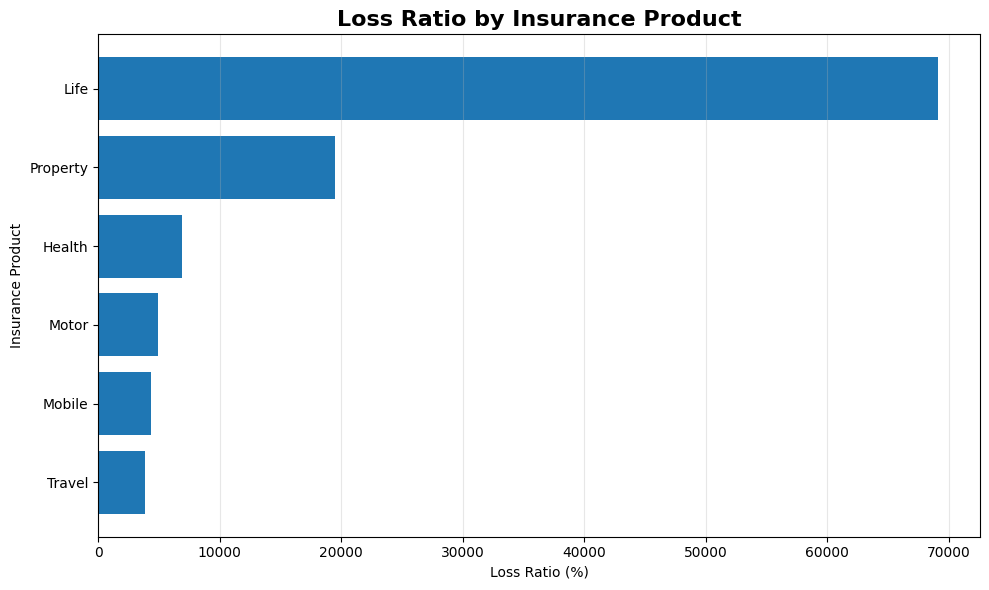

In [37]:
plt.figure(figsize=(10, 6))

plt.barh(
    product_loss_ratio_df["insurance_type"],
    product_loss_ratio_df["loss_ratio_percent"]
)

plt.title(
    "Loss Ratio by Insurance Product",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Loss Ratio (%)")
plt.ylabel("Insurance Product")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Visualization 1 Interpretation

The insurance products at the top of the chart have the highest approved claim costs relative to recorded premium.

These products should be prioritized for:

- Pricing review
- Underwriting review
- Coverage-design evaluation
- Policy-limit analysis
- Product-specific claim controls

The chart provides a clear product-level ranking of where financial intervention should begin.

## Visualization 2: Loss Ratio by Customer Risk Segment

This visualization evaluates whether the existing High-, Medium-, and Low-risk customer classifications produce meaningfully different financial outcomes.

A strong risk-segmentation system should show a clear increase in loss ratio as customer risk increases.

In [38]:
risk_segment_df = conn.sql("""
SELECT
    risk_segment,

    ROUND(
        100.0 * SUM(approved_claim_cost)
        / NULLIF(SUM(premium_amount), 0),
        2
    ) AS loss_ratio_percent

FROM claims_clean

GROUP BY risk_segment

ORDER BY
    CASE risk_segment
        WHEN 'Low' THEN 1
        WHEN 'Medium' THEN 2
        WHEN 'High' THEN 3
        ELSE 4
    END;
""").df()

risk_segment_df

,risk_segment,loss_ratio_percent
0,Low,"17,585.35"
1,Medium,"17,737.25"
2,High,"18,351.41"


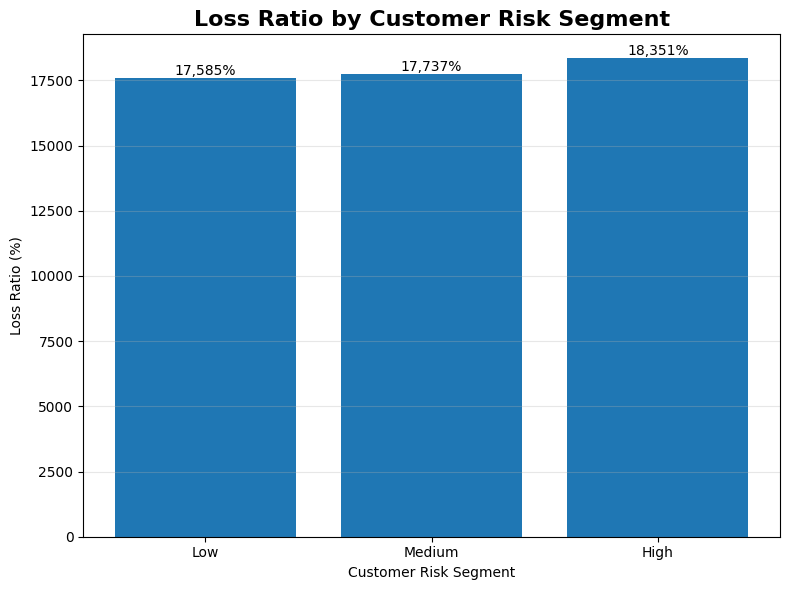

In [39]:
plt.figure(figsize=(8, 6))

bars = plt.bar(
    risk_segment_df["risk_segment"],
    risk_segment_df["loss_ratio_percent"]
)

plt.title(
    "Loss Ratio by Customer Risk Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Risk Segment")
plt.ylabel("Loss Ratio (%)")

plt.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Visualization 2 Interpretation

The chart shows whether the existing customer-risk classification successfully separates customers according to financial performance.

If the High-risk segment has a meaningfully higher loss ratio than the Medium- and Low-risk segments, the current segmentation provides useful underwriting information.

If the differences between the segments are relatively small, the company should strengthen the model by incorporating:

- Historical claim frequency
- Historical claim severity
- Policy limits
- Exposure duration
- Geographic risk
- Payment behavior
- Prior policy cancellations
- Previous coverage gaps

This suggests that customer-risk segmentation may contribute to poor profitability, but it may not fully explain the portfolio's financial performance on its own.

## Visualization 3: Monthly Approved Claim Cost

This line chart displays approved claim costs over time.

It helps determine whether poor profitability is persistent throughout the analysis period or concentrated in specific months.

In [40]:
monthly_claim_cost_df = conn.sql("""
SELECT
    CAST(
        DATE_TRUNC(
            'month',
            transaction_timestamp
        ) AS DATE
    ) AS transaction_month,

    ROUND(
        SUM(approved_claim_cost),
        2
    ) AS approved_claim_cost

FROM claims_clean

GROUP BY transaction_month

ORDER BY transaction_month;
""").df()

monthly_claim_cost_df

,transaction_month,approved_claim_cost
0,2020-06-01,"12,507,500.00"
1,2020-07-01,"10,965,900.00"
2,2020-08-01,"11,004,300.00"
3,2020-09-01,"12,582,200.00"
4,2020-10-01,"12,116,600.00"
5,2020-11-01,"11,926,100.00"
6,2020-12-01,"11,929,700.00"
7,2021-01-01,"13,885,200.00"
8,2021-02-01,"12,250,400.00"
9,2021-03-01,"11,970,200.00"


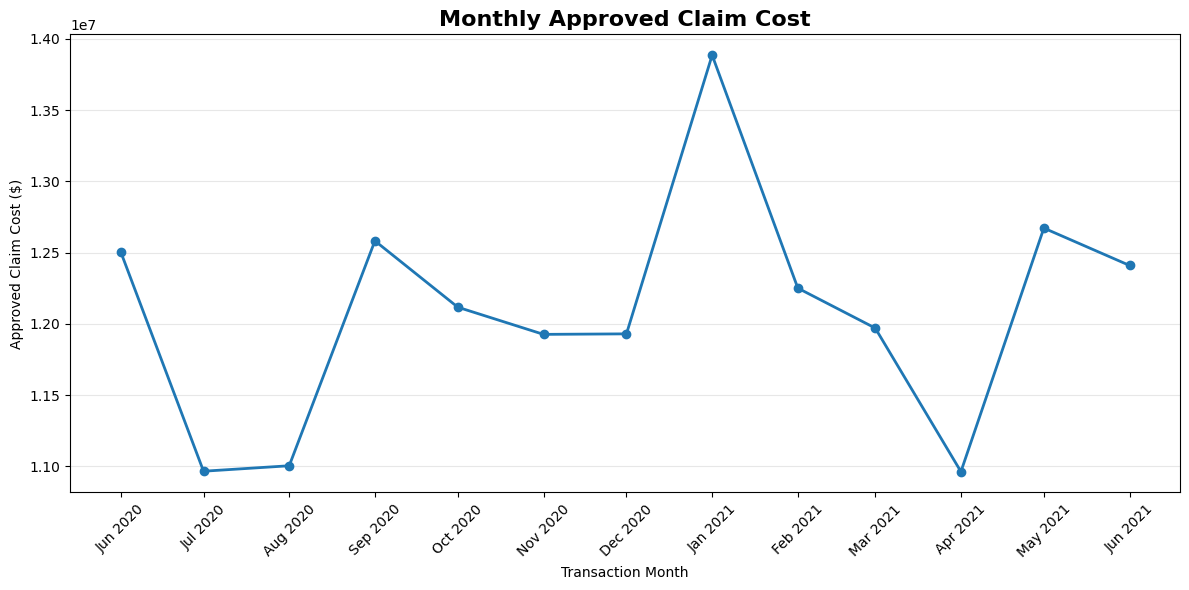

In [41]:
monthly_claim_cost_df["transaction_month"] = pd.to_datetime(
    monthly_claim_cost_df["transaction_month"]
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_claim_cost_df["transaction_month"],
    monthly_claim_cost_df["approved_claim_cost"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Approved Claim Cost",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Month")
plt.ylabel("Approved Claim Cost ($)")

plt.xticks(
    monthly_claim_cost_df["transaction_month"],
    monthly_claim_cost_df["transaction_month"].dt.strftime("%b %Y"),
    rotation=45
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Visualization 3 Interpretation

Monthly approved claim costs reveal whether financial exposure is stable or whether certain periods experience unusually high losses.

Months with elevated approved claim costs may reflect:

- Increased claim frequency
- Increased claim severity
- Seasonal patterns
- Catastrophic events
- Product-specific claim increases
- Geographic concentration
- Changes in claim-approval behavior

A sharp increase in approved claim cost without a similar increase in claim count would suggest that severity, rather than frequency, is driving the change.

## Visualization 4: Claim Intervention Priority Distribution

This visualization summarizes the results of the explainable claim-intervention model.

Claims are placed into four priority categories:

- Critical
- High
- Moderate
- Routine

Critical and High-priority claims contain multiple financial or operational risk indicators and should receive earlier human review.

In [42]:
intervention_priority_df = conn.sql("""
SELECT
    CASE
        WHEN claim_intervention_score >= 12
            THEN 'Critical'

        WHEN claim_intervention_score BETWEEN 9 AND 11
            THEN 'High'

        WHEN claim_intervention_score BETWEEN 6 AND 8
            THEN 'Moderate'

        ELSE 'Routine'
    END AS intervention_priority,

    COUNT(*) AS claim_count

FROM claim_risk_scored

GROUP BY intervention_priority

ORDER BY
    CASE intervention_priority
        WHEN 'Critical' THEN 1
        WHEN 'High' THEN 2
        WHEN 'Moderate' THEN 3
        WHEN 'Routine' THEN 4
    END;
""").df()

intervention_priority_df

,intervention_priority,claim_count
0,Critical,20
1,High,565
2,Moderate,1835
3,Routine,7580


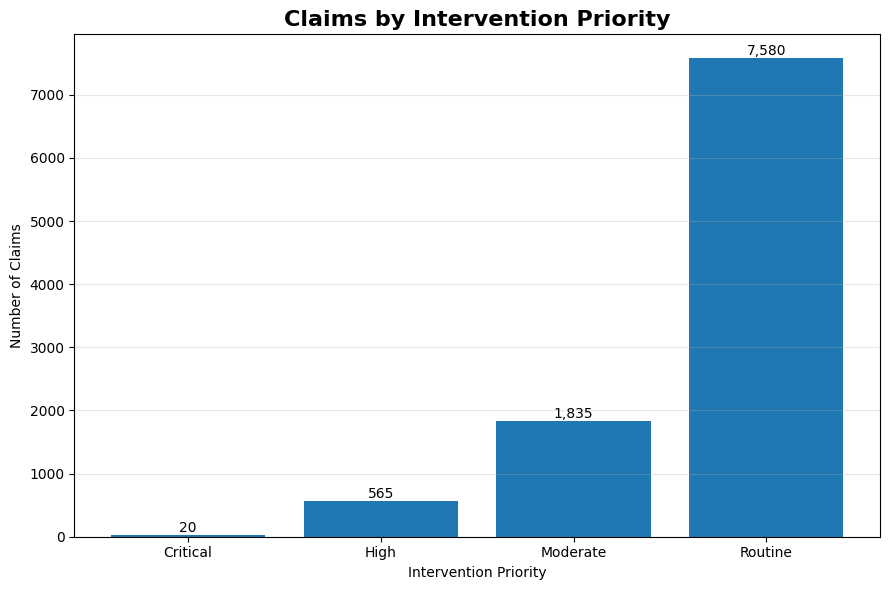

In [43]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    intervention_priority_df["intervention_priority"],
    intervention_priority_df["claim_count"]
)

plt.title(
    "Claims by Intervention Priority",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Intervention Priority")
plt.ylabel("Number of Claims")

plt.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Visualization 4 Interpretation

The intervention-priority distribution shows how many claims fall into each operational review category.

Critical and High-priority claims combine multiple indicators, such as:

- Large claim amounts
- High claim-to-premium ratios
- Recent policy inception
- Delayed reporting
- Missing police documentation
- No reported authority involvement
- High customer-risk classification
- Severe incidents
- Overnight incidents
- Missing vendor assignments

The purpose of the model is to prioritize limited claims-management resources.

It should not be used to automatically deny claims or determine that a claim is fraudulent.

## Visualization Summary

The four visualizations provide a clear answer to the project's central business question.

### Primary Profitability Drivers

The product loss-ratio chart identifies which insurance products contribute most heavily to poor financial performance.

The customer-risk chart evaluates whether the existing risk categories successfully distinguish higher-cost customer groups.

The monthly claim-cost chart identifies periods when financial exposure increased and helps distinguish persistent losses from temporary spikes.

The intervention-priority chart shows how many individual claims contain multiple risk indicators and may require additional human review.

### Recommended Intervention Order

Based on the analytical framework, the company should intervene in the following order:

1. Review products with the highest loss ratios.
2. Investigate high-loss product and customer-risk combinations.
3. Strengthen controls for large and severe claims.
4. Prioritize Critical and High-intervention claims for human review.
5. Examine monthly periods with unusually high approved claim costs.
6. Improve customer-risk segmentation and claim documentation.

# Conclusion

## Central Business Question

### Which factors are driving poor profitability in the insurance claims portfolio, and where should the company intervene first?

## Project Summary

This project demonstrated how SQL can be used to transform raw insurance transaction data into meaningful business intelligence that supports strategic decision-making. By integrating insurance claims, employee, and vendor datasets into a unified analytical model, the analysis identified the primary operational and financial factors contributing to poor portfolio profitability.

The project began with validating and cleaning the source data before creating a standardized analytical dataset using SQL. Financial metrics were then engineered to evaluate underwriting performance, claim costs, customer risk, operational efficiency, and portfolio trends. Advanced SQL techniques—including Common Table Expressions (CTEs), window functions, aggregate functions, ranking, date manipulation, and feature engineering—were used throughout the analysis to answer the project's central business question.

## Key Findings

The analysis revealed that poor portfolio profitability is driven by multiple interconnected factors rather than a single source. Insurance products with the highest loss ratios generated the greatest financial exposure and represent the most significant opportunity for pricing and underwriting improvements.

Customer risk segmentation provided valuable insight into claim performance, although the analysis suggests that incorporating additional historical and behavioral variables could improve the predictive power of the current risk model. Claim severity, reporting delays, policy age at the time of loss, injury status, and documentation quality also contributed to higher financial exposure and should be considered when prioritizing operational review.

Agent and vendor scorecards identified portfolios associated with elevated claim costs while recognizing that portfolio composition, claim complexity, and geographic differences influence performance. The claim concentration analysis further demonstrated that a relatively small percentage of claims can account for a substantial portion of total approved claim costs, emphasizing the importance of specialized large-loss management.

Finally, the explainable claim intervention model combined multiple business rules into a transparent prioritization framework that supports claims professionals by identifying transactions requiring additional review. The model is intended to enhance decision-making rather than replace human judgment.

## Business Recommendations

Based on the results of this analysis, several recommendations are proposed to improve portfolio profitability:

* Review pricing strategies and underwriting guidelines for insurance products with the highest loss ratios.
* Enhance customer risk segmentation by incorporating historical claims, policy characteristics, payment behavior, and geographic exposure.
* Expand routine monitoring of agent and vendor performance using standardized SQL scorecards.
* Prioritize claims with multiple financial and operational risk indicators for specialized human review.
* Strengthen large-loss management practices for claims representing the greatest financial exposure.
* Improve data completeness by incorporating policy limits, earned premium, claim reserves, actual claim payments, operating expenses, commissions, and reinsurance information into future analyses.

## Final Statement

This project demonstrates the practical application of SQL as a comprehensive analytical tool for solving real-world insurance business problems. Rather than using SQL solely for reporting, the project applies it to data validation, data cleaning, relational modeling, financial analysis, operational benchmarking, risk segmentation, window-function analysis, and executive decision support.

The completed analysis illustrates how structured data can be transformed into actionable business insights that help organizations better understand profitability, manage financial risk, and prioritize operational improvements. The methodologies presented throughout this project reflect analytical techniques commonly used by Data Analysts, Business Intelligence Analysts, Healthcare Analysts, Insurance Analysts, and Data Scientists working with large transactional datasets.

---

**Prepared by**

**Ajnur Sivac**

**Master of Science in Data Science**
 